In [1]:
import sys
sys.path.append('..')  # Ajoutez le répertoire parent au chemin d'importation

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.models.model import ChestXRayClassifier
from src.data.preprocessing import create_data_loaders
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import os
model_path = os.path.join('..', 'best_model.pth')
print(f"Chemin du modèle: {model_path}")
print(f"Le modèle existe: {os.path.exists(model_path)}")

def evaluate_notebook(threshold=0.6, model_path='best_model.pth'):
    """Enhanced evaluation with threshold adjustment and error analysis"""
    # Load model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ChestXRayClassifier.load_from_checkpoint(model_path, device)
    
    # Load test data
    _, _, test_loader = create_data_loaders('../data/raw/chest_xray')
    
    # Evaluation
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            
            # Threshold adjustment
            preds = (probabilities[:, 1] > threshold).long()
            
            all_probs.extend(probabilities.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Confusion matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    
    # Classification report with adjusted threshold
    print(f"\nClassification Report (Threshold={threshold}):")
    print(classification_report(
        all_labels, all_preds,
        target_names=['NORMAL', 'PNEUMONIA']
    ))
    
    # Return values for further analysis
    return {
        'labels': np.array(all_labels),
        'preds': np.array(all_preds),
        'probs': np.array(all_probs)
    }

# Utilisez cette fonction au lieu de l'originale
results = evaluate_notebook(threshold=0.6, model_path=model_path)

Chemin du modèle: ..\best_model.pth
Le modèle existe: True
Train: 2724 images, Val: 2508 images, Test: 624 images

Confusion Matrix:
[[160  74]
 [  4 386]]

Classification Report (Threshold=0.6):
              precision    recall  f1-score   support

      NORMAL       0.98      0.68      0.80       234
   PNEUMONIA       0.84      0.99      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



In [3]:
# Get indices of errors
fp_indices = np.where((results['labels'] == 0) & (results['preds'] == 1))[0]  # False Pneumonia
fn_indices = np.where((results['labels'] == 1) & (results['preds'] == 0))[0]  # Missed Pneumonia

print(f"False Positives (Normal predicted as Pneumonia): {len(fp_indices)}")
print(f"False Negatives (Pneumonia predicted as Normal): {len(fn_indices)}")

False Positives (Normal predicted as Pneumonia): 74
False Negatives (Pneumonia predicted as Normal): 4


Le chemin vers les données existe : True
Train: 2724 images, Val: 2508 images, Test: 624 images


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9843137..1.7019608].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9529412..1.8431373].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9215686..1.6862745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..1.9843137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..1.7647059].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7960784..1.8588235].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..1.6705883].
Cli

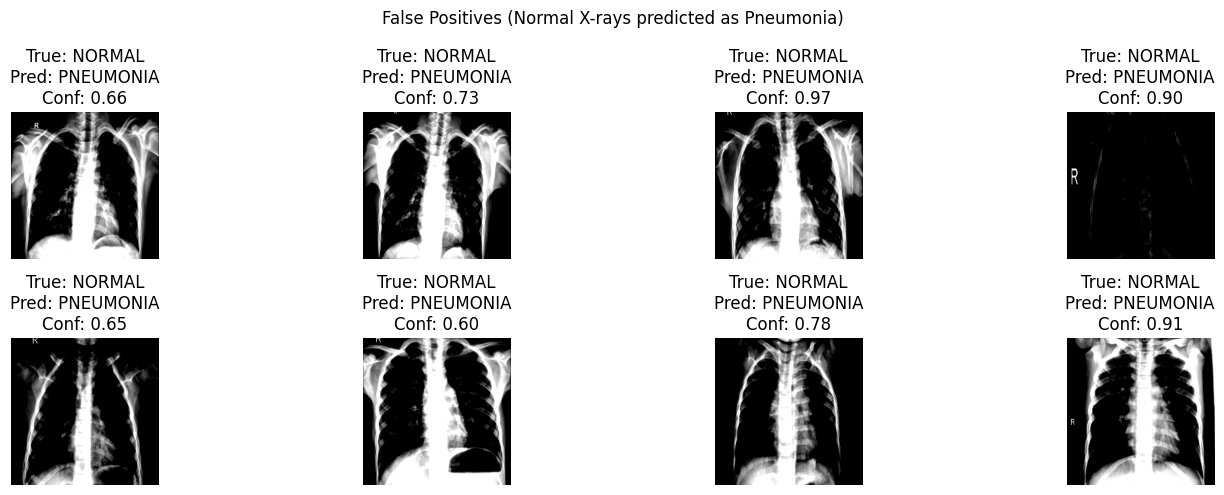

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..1.9215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..1.8745098].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..1.8901961].


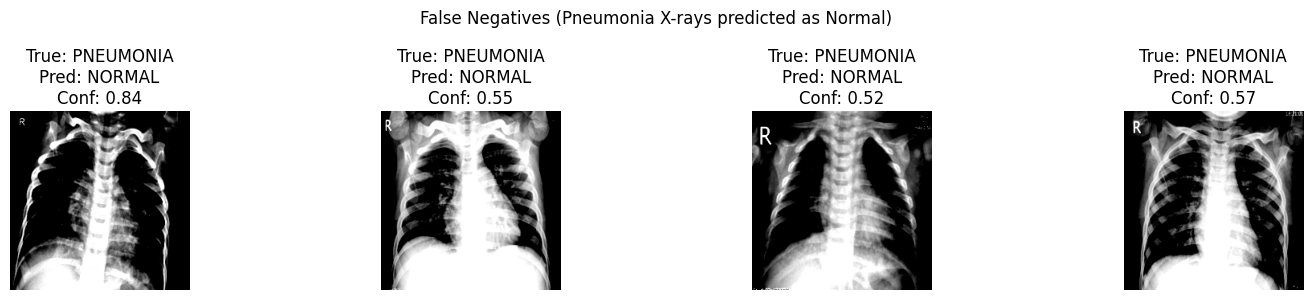

In [4]:
# Load test data
# Dans le notebook, utilisez un chemin relatif qui remonte d'un niveau
import os
data_dir = os.path.join('..', 'data', 'raw', 'chest_xray')

# Vérifiez que le chemin existe
print(f"Le chemin vers les données existe : {os.path.exists(data_dir)}")

# Utilisez ce chemin pour charger les données
_, _, test_loader = create_data_loaders(data_dir)
test_dataset = test_loader.dataset

def show_errors(indices, title):
    """Display images with true/predicted labels"""
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices[:8]):  # Show first 8 errors
        image, label = test_dataset[idx]
        prob = results['probs'][idx]
        
        plt.subplot(2, 4, i+1)
        plt.imshow(image.permute(1, 2, 0).numpy())
        plt.title(f"True: {'PNEUMONIA' if label else 'NORMAL'}\n"
                  f"Pred: {'PNEUMONIA' if results['preds'][idx] else 'NORMAL'}\n"
                  f"Conf: {max(prob):.2f}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Display errors
if len(fp_indices) > 0:
    show_errors(fp_indices, "False Positives (Normal X-rays predicted as Pneumonia)")
    
if len(fn_indices) > 0:
    show_errors(fn_indices, "False Negatives (Pneumonia X-rays predicted as Normal)")

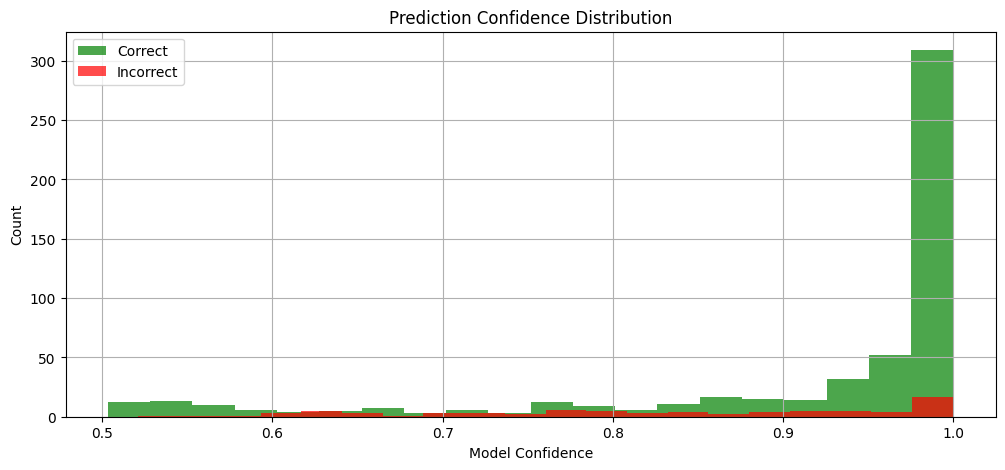

In [5]:
# Plot confidence distributions
plt.figure(figsize=(12, 5))

# Correct predictions
correct_mask = (results['labels'] == results['preds'])
plt.hist(np.max(results['probs'][correct_mask], axis=1), bins=20, 
         alpha=0.7, label='Correct', color='green')

# Incorrect predictions
incorrect_mask = (results['labels'] != results['preds'])
plt.hist(np.max(results['probs'][incorrect_mask], axis=1), bins=20, 
         alpha=0.7, label='Incorrect', color='red')

plt.xlabel('Model Confidence')
plt.ylabel('Count')
plt.title('Prediction Confidence Distribution')
plt.legend()
plt.grid(True)
plt.show()

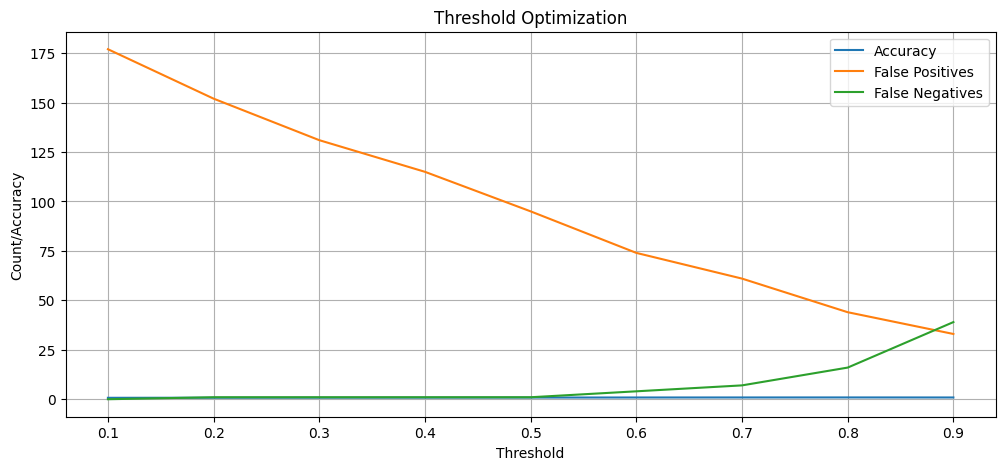

In [6]:
# Test multiple thresholds
thresholds = np.linspace(0.1, 0.9, 9)
metrics = []

for thresh in thresholds:
    preds = (results['probs'][:, 1] > thresh).astype(int)
    correct = (preds == results['labels']).mean()
    metrics.append({
        'threshold': thresh,
        'accuracy': correct,
        'false_positives': ((preds == 1) & (results['labels'] == 0)).sum(),
        'false_negatives': ((preds == 0) & (results['labels'] == 1)).sum()
    })

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(thresholds, [m['accuracy'] for m in metrics], label='Accuracy')
plt.plot(thresholds, [m['false_positives'] for m in metrics], label='False Positives')
plt.plot(thresholds, [m['false_negatives'] for m in metrics], label='False Negatives')
plt.xlabel('Threshold')
plt.ylabel('Count/Accuracy')
plt.title('Threshold Optimization')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# Chargez le modèle avant de visualiser les prédictions
import os
from src.models.model import ChestXRayClassifier
from src.visualization.visualize import visualize_predictions

# Définir le dispositif
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Charger le modèle
model_path = os.path.join('..', 'best_model.pth')
model = ChestXRayClassifier.load_from_checkpoint(model_path, device=device)
model.eval()  # Mettre en mode évaluation

# Maintenant vous pouvez visualiser les prédictions
visualize_predictions(
    model=model,
    dataloader=test_loader,
    device=device,
    num_images=8
)


ModuleNotFoundError: No module named 'src'